<a href="https://colab.research.google.com/github/SutamaSarkar/RealiabilitySimulation/blob/main/activestandby.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import random
import matplotlib.pyplot as plt
import math

In [26]:
lamda= 0.001
beta=1
theta=1000
t=[100,500,1000]
Reliability_analytical_100 = math.exp(-lamda * 100) * (1 + (lamda * 100))
print("Analytical Reliability at t(100) is = ",Reliability_analytical_100)
Reliability_analytical_500 = math.exp(-lamda * 500) * (1 + (lamda * 500))
print("Analytical Reliability at t(500) is = ",Reliability_analytical_500)
Reliability_analytical_1000 = math.exp(-lamda * 1000) * (1 + (lamda * 1000))
print("Analytical Reliability at t(1000) is = ",Reliability_analytical_1000)

Analytical Reliability at t(100) is =  0.9953211598395556
Analytical Reliability at t(500) is =  0.9097959895689501
Analytical Reliability at t(1000) is =  0.7357588823428847


In [27]:
N=1000000
a=0
b=1
sum_1=0
sum_2=0
sum_3=0
for i in range(1,N+1):
  Fa=random.uniform(a,b)
  Fb=random.uniform(a,b)
  ta=-math.log(1-Fa)/lamda
  tb=-(math.log(1-Fb)*theta)**(1/beta)
  t_total=ta+tb

  if(t_total>100):
    sum_1+=1
  if(t_total>500):
    sum_2+=1
  if(t_total>1000):
    sum_3+=1

probability_1=sum_1/N
probability_2=sum_2/N
probability_3=sum_3/N
print("Experimental Reliability at t(100) is =",probability_1)
print("Experimental Reliability at t(500) is =",probability_2)
print("Experimental Reliability at t(1000) is =",probability_3)


Experimental Reliability at t(100) is = 0.995411
Experimental Reliability at t(500) is = 0.910151
Experimental Reliability at t(1000) is = 0.736482


In [29]:
trial_list=[100,1000,10000,100000,1000000]
N_list= []
Rel_100_list=[]
Rel_500_list=[]
Rel_1000_list=[]
print("\nTRIALS(N)\tReliability_100\t\tReliability_500\t\tReliability_1000")
print("_________________________________________________________________________")
for N in trial_list:
    a=0
    b=1
    for i in range(1,N+1):
      Fa=random.uniform(a,b)
      Fb=random.uniform(a,b)
      ta=-math.log(1-Fa)/lamda
      tb=-(math.log(1-Fb)*theta)**(1/beta)
      t_total=ta+tb

      if(t_total>100):
        sum_1+=1
      if(t_total>500):
        sum_2+=1
      if(t_total>1000):
        sum_3+=1

    probability_1=sum_1/N
    probability_2=sum_2/N
    probability_3=sum_3/N

     N_list.append(N)
     Rel_100_list.append(probability_1)
     Rel_500_list.append(probability_2)
     Rel_1000_list.append(probability_3)

for i in range(len(N_list)):
    print(f"{N_list[i]}\t\t{Rel_100_list[i]}\t\t\t{Rel_500_list[i]}\t\t\t{Rel_1000_list[i]}")

plt.figure(figsize=(5,5))

plt.plot(N_list,,


plt.xscale("log")
plt.xlabel("Number of Trials ")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of series")
plt.legend()
plt.grid(True)
plt.show()




IndentationError: unexpected indent (1829735025.py, line 29)


TRIALS(N)	Reliability_50	Reliability_100	Reliability_500	Reliability_1000
-----------------------------------------------------------------------
100			1.0000			0.9100			0.7900			1.0000
1000			0.9940			0.9090			0.7300			0.9950
10000			0.9940			0.9146			0.7343			0.9985
100000			0.9952			0.9091			0.7354			0.9987
1000000			0.9954			0.9098			0.7363			0.9988


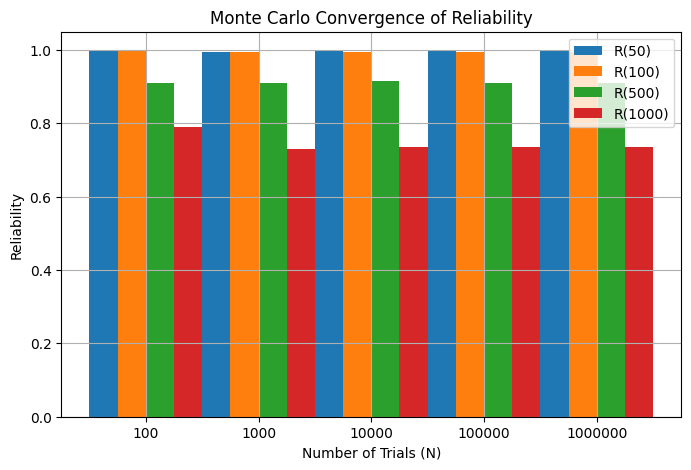

In [33]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

trial_list=[100,1000,10000,100000,1000000]

N_list=[]
Rel_50_list=[]
Rel_100_list=[]
Rel_500_list=[]
Rel_1000_list=[]

lamda=0.001
theta=1000
beta=1

print("\nTRIALS(N)\tReliability_50\tReliability_100\tReliability_500\tReliability_1000")
print("-----------------------------------------------------------------------")

for N in trial_list:

    sum_1=0
    sum_2=0
    sum_3=0
    sum_4=0

    for i in range(N):

        Fa=random.uniform(0,1)
        Fb=random.uniform(0,1)

        ta=-math.log(1-Fa)/lamda
        tb=theta*(-math.log(1-Fb))**(1/beta)

        t_total=ta+tb

        if t_total>50:
            sum_4+=1

        if t_total>100:
            sum_1+=1
        if t_total>500:
            sum_2+=1
        if t_total>1000:
            sum_3+=1

    probability_1=sum_1/N
    probability_2=sum_2/N
    probability_3=sum_3/N
    probability_4=sum_4/N

    N_list.append(N)
    Rel_100_list.append(probability_1)
    Rel_500_list.append(probability_2)
    Rel_1000_list.append(probability_3)
    Rel_50_list.append(probability_4)

    print(f"{N}\t\t\t{probability_1:.4f}\t\t\t{probability_2:.4f}\t\t\t{probability_3:.4f}\t\t\t{probability_4:.4f}")


x=np.arange(len(N_list))
width=0.25

plt.figure(figsize=(8,5))

plt.bar(x - 1.5*width, Rel_50_list, width, label="R(50)")
plt.bar(x - 0.5*width, Rel_100_list, width, label="R(100)")
plt.bar(x + 0.5*width, Rel_500_list, width, label="R(500)")
plt.bar(x + 1.5*width, Rel_1000_list, width, label="R(1000)")

plt.xticks(x,N_list)

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability")

plt.legend()
plt.grid(True)

plt.show()


TRIALS(N)	Reliability_100	Reliability_500	Reliability_1000
-----------------------------------------------------------------------
100		1.0000		0.9600		0.8000
1000		0.9970		0.9380		0.7560
10000		0.9986		0.9461		0.7769
100000		0.9988		0.9459		0.7755
1000000		0.9988		0.9446		0.7740


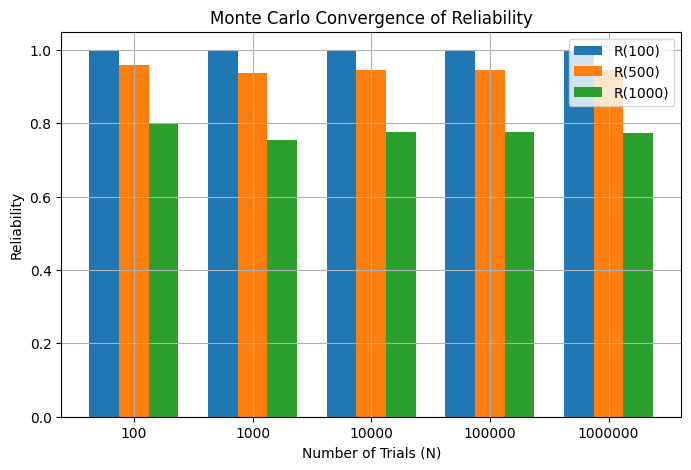

In [35]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

trial_list=[100,1000,10000,100000,1000000]

N_list=[]
Rel_100_list=[]
Rel_500_list=[]
Rel_1000_list=[]

lamda=0.001
theta=1000
beta=1.5

print("\nTRIALS(N)\tReliability_100\tReliability_500\tReliability_1000")
print("-----------------------------------------------------------------------")

for N in trial_list:

    sum_1=0
    sum_2=0
    sum_3=0

    for i in range(N):

        Fa=random.uniform(0,1)
        Fb=random.uniform(0,1)

        ta=-math.log(1-Fa)/lamda
        tb=theta*(-math.log(1-Fb))**(1/beta)

        t_total=ta+tb

        if t_total>100:
            sum_1+=1
        if t_total>500:
            sum_2+=1
        if t_total>1000:
            sum_3+=1

    probability_1=sum_1/N
    probability_2=sum_2/N
    probability_3=sum_3/N

    N_list.append(N)
    Rel_100_list.append(probability_1)
    Rel_500_list.append(probability_2)
    Rel_1000_list.append(probability_3)

    print(f"{N}\t\t{probability_1:.4f}\t\t{probability_2:.4f}\t\t{probability_3:.4f}")

# ---------- BAR CHART ----------

x=np.arange(len(N_list))
width=0.25

plt.figure(figsize=(8,5))

plt.bar(x-width,Rel_100_list,width,label="R(100)")
plt.bar(x,Rel_500_list,width,label="R(500)")
plt.bar(x+width,Rel_1000_list,width,label="R(1000)")

plt.xticks(x,N_list)

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability")

plt.legend()
plt.grid(True)

plt.show()


TRIALS(N)	Reliability_100	Reliability_500	Reliability_1000
-----------------------------------------------------------------------
100		1.0000		0.9500		0.7600
1000		0.9990		0.9450		0.7820
10000		0.9983		0.9412		0.7729
100000		0.9988		0.9450		0.7740
1000000		0.9988		0.9443		0.7743


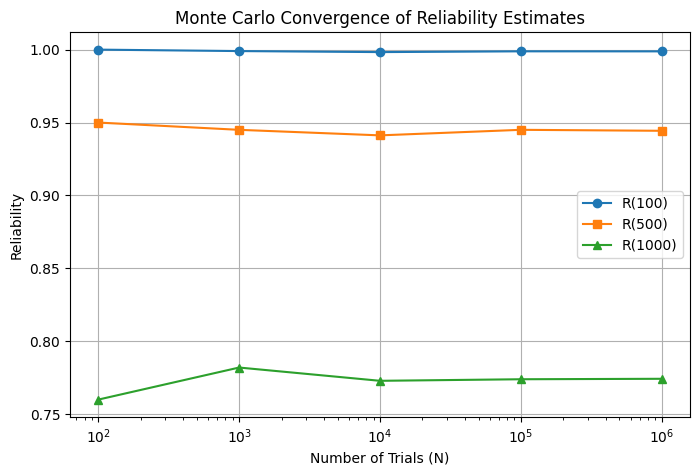

In [36]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

trial_list=[100,1000,10000,100000,1000000]

N_list=[]
Rel_100_list=[]
Rel_500_list=[]
Rel_1000_list=[]

lamda=0.001
theta=1000
beta=1.5

print("\nTRIALS(N)\tReliability_100\tReliability_500\tReliability_1000")
print("-----------------------------------------------------------------------")

for N in trial_list:

    sum_1=0
    sum_2=0
    sum_3=0

    for i in range(N):

        Fa=random.uniform(0,1)
        Fb=random.uniform(0,1)

        ta=-math.log(1-Fa)/lamda
        tb=theta*(-math.log(1-Fb))**(1/beta)

        t_total=ta+tb

        if t_total>100:
            sum_1+=1
        if t_total>500:
            sum_2+=1
        if t_total>1000:
            sum_3+=1

    probability_1=sum_1/N
    probability_2=sum_2/N
    probability_3=sum_3/N

    N_list.append(N)
    Rel_100_list.append(probability_1)
    Rel_500_list.append(probability_2)
    Rel_1000_list.append(probability_3)

    print(f"{N}\t\t{probability_1:.4f}\t\t{probability_2:.4f}\t\t{probability_3:.4f}")

# ---------- BAR CHART ----------

plt.figure(figsize=(8,5))

plt.plot(N_list,Rel_100_list,marker='o',label="R(100)")
plt.plot(N_list,Rel_500_list,marker='s',label="R(500)")
plt.plot(N_list,Rel_1000_list,marker='^',label="R(1000)")

plt.xscale("log")   # log scale shows convergence clearly

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability Estimates")

plt.legend()
plt.grid(True)

plt.show()